# Infrastructure-Based Adaptive Capacity: Access to Heat-Mitigating Resources and Essential Services
Adaptive capacity refers to the ability of individuals, communities, or systems to adjust to potential hazards, take advantage of opportunities, or cope with consequences. In the context of urban heat vulnerability, adaptive capacity is largely determined by proximity to and availability of infrastructure and services that can buffer heat stress - whether by providing cooling refuge, emergency care, or basic physiological needs such as hydration.
Following the widely used $$Vulnerability = Exposure * Sensitivity * Adaptive\ Capacity$$ framework (IPCC, 2014; Cutter et al., 2003), this section operationalises adaptive capacity through spatial accessibility indicators, quantifying how well different areas of Nairobi are served by key heat-mitigating resources.

## Setup

In [1]:
import sys
sys.path.append('../.')

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from src.adaptive_capacity_helper import *
from src.export_web_maps import *

%load_ext autoreload
%autoreload 2
%matplotlib inline

Failed to read module file 'C:\Users\Surface\anaconda3\Lib\shlex.py' for module 'shlex': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-ETHOS\Nairobi_Heat_Vulnerability_Assessment\nairobi_env\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-ETHOS\Nairobi_Heat_Vulnerability_Assessment\nairobi_env\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Surface\anaconda3\Lib\importlib\__init__.py", line 126, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1204, in _gcd_import
  File "<frozen importlib.

In [2]:
# --- Load boundary & create analysis grid -----------------------------
boundary = load_boundary()  # reads data/geospatial/nairobi_boundary.geojson
grid = create_analysis_grid(boundary, resolution_m=50)
print(f"Grid shape: {grid['nrows']} rows x {grid['ncols']} cols")
print(f"Cells inside boundary: {grid['mask'].sum():,}")

  Grid created: 631 x 982 cells (50 m resolution)
Grid shape: 631 rows x 982 cols
Cells inside boundary: 278,559


In [3]:
# --- Compute adaptive capacity over INHABITED areas only -------------------
# Don't mask after the fact - normalise WHERE PEOPLE LIVE. compute_proximity /
# compute_road_density normalise over grid['mask']; if that includes the empty
# park/desert, the farthest pixel sits out there and every inhabited pixel gets
# squashed near "good access". Passing grid_pop (mask = inhabited) means the
# distance, the normalisation, AND the output are all restricted to the city,
# so the scores span the full 0-1 range inside it and real variation is visible.
from src.sensitivity_helper import resample_to_grid
from rasterio.enums import Resampling

_pop = resample_to_grid(
    os.path.join(DATA_DIR, '2_sensitivity', 'nairobi_general_pop_2020.tif'),
    grid, method=Resampling.sum)
pop_mask = (_pop > 0) & grid['mask'] if _pop is not None else grid['mask'].copy()
grid_pop = {**grid, 'mask': pop_mask}   # same grid; "valid area" = inhabited only
print(f"Inhabited cells: {pop_mask.sum():,} / {grid['mask'].sum():,} "
      f"({pop_mask.sum() / grid['mask'].sum() * 100:.1f}% of city)")


def mask_uninhabited(raster):
    """Set uninhabited pixels to NaN (used for layers already on the full grid)."""
    out = np.asarray(raster, dtype='float32').copy()
    out[~pop_mask] = np.nan
    return out


def plot_inhabited(raster, grid, title, **kwargs):
    """plot_layer, colour-stretched to the 2-98 percentile of the valid pixels."""
    m = mask_uninhabited(raster)
    finite = m[np.isfinite(m)]
    if len(finite):
        kwargs.setdefault('vmin', float(np.percentile(finite, 2)))
        kwargs.setdefault('vmax', float(np.percentile(finite, 98)))
    return plot_layer(m, grid, title, **kwargs)

Inhabited cells: 146,675 / 278,559 (52.7% of city)


## 1 · Proximity to retail & food supply
Access to food and basic supplies is critical during heat events. This layer measures the Euclidean distance from every 50 m grid cell to the nearest retail/food point (supermarkets, convenience stores, marketplaces) sourced from OpenStreetMap.

  Loaded 3_adaptivity/retail_food_nairobi.geojson: 653 features


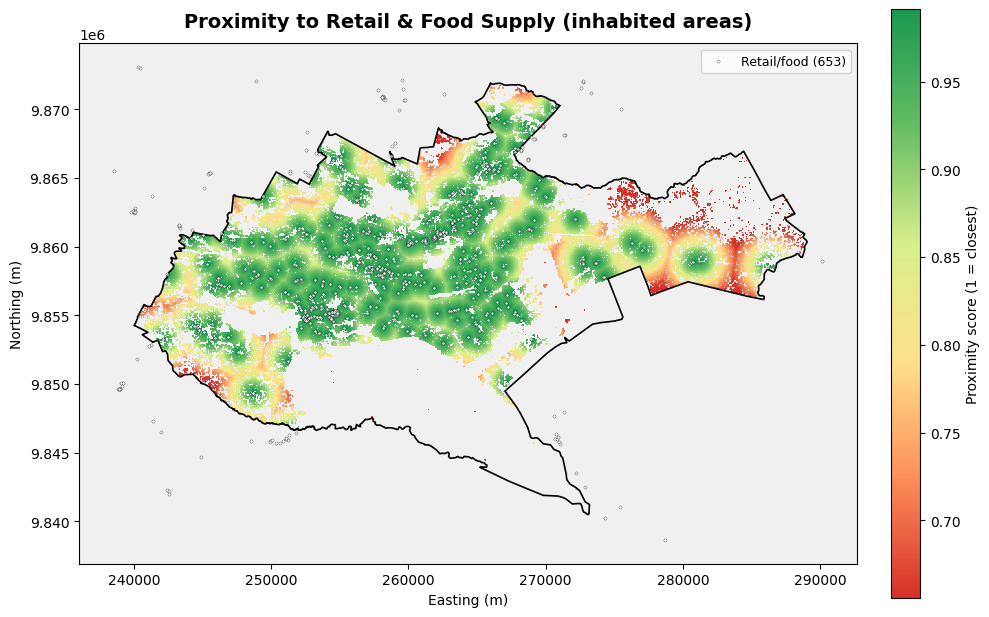

In [4]:
retail = load_geojson('3_adaptivity/retail_food_nairobi.geojson')

retail_proximity = compute_proximity(retail, grid_pop)   # normalise over inhabited area

fig, ax = plt.subplots(figsize=(10, 9))
plot_inhabited(retail_proximity, grid,
           'Proximity to Retail & Food Supply (inhabited areas)',
           cbar_label='Proximity score (1 = closest)', ax=ax)
plot_points_overlay(retail, grid, ax, color='white', size=5,
                    label=f'Retail/food ({len(retail)})')
plt.tight_layout()
plt.show();

## 2 · Healthcare accessibility
Proximity to health facilities determines how quickly residents can receive treatment for heat-related illness. We use the Kenya health-facilities dataset, filtered to Nairobi province.

  Loaded 3_adaptivity/Health_facilities_Nairobi.geojson: 4867 features
  Filtered to Nairobi: 169 facilities


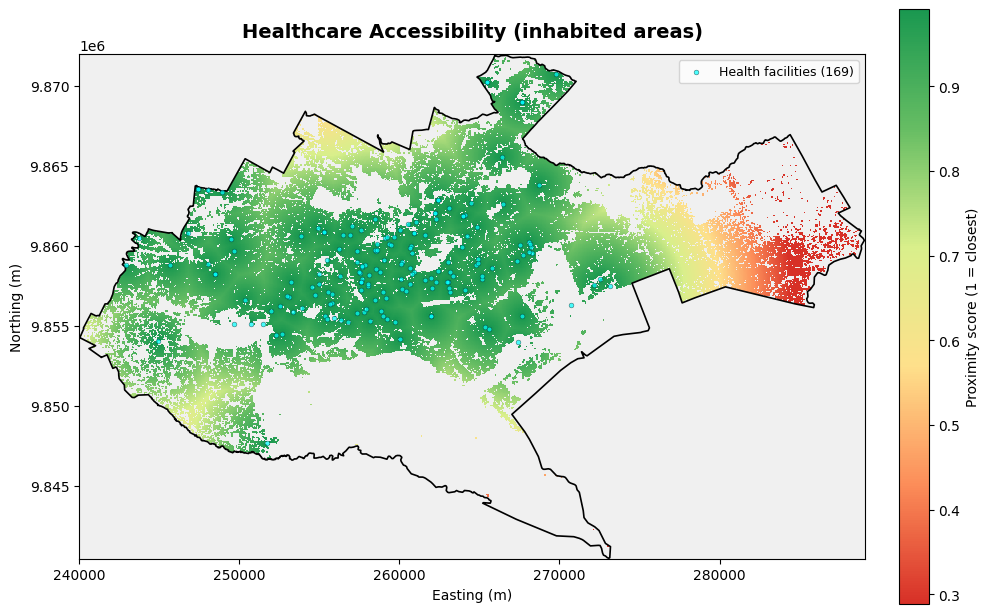

In [5]:
health_all = load_geojson('3_adaptivity/Health_facilities_Nairobi.geojson')

# Filter to Nairobi province
health = health_all[health_all['Province'] == 'NAIROBI'].copy()
print(f"  Filtered to Nairobi: {len(health)} facilities")

health_proximity = compute_proximity(health, grid_pop)   # normalise over inhabited area

fig, ax = plt.subplots(figsize=(10, 9))
plot_inhabited(health_proximity, grid,
           'Healthcare Accessibility (inhabited areas)',
           cbar_label='Proximity score (1 = closest)', ax=ax)
plot_points_overlay(health, grid, ax, color='cyan', size=12,
                    label=f'Health facilities ({len(health)})')
plt.tight_layout()
plt.show();

## 3 · Access to safe water sources
Hydration access is one of the most direct determinants of heat-stress resilience. This layer uses OSM drinking water points, water wells, and taps.

> **Caveat:** OSM coverage of water points in informal settlements is known to be incomplete, many informal water vendors are not mapped. Maybe the wheight that we give to this layer should be set accordingly

  Loaded 3_adaptivity/water_sources_nairobi.geojson: 3266 features


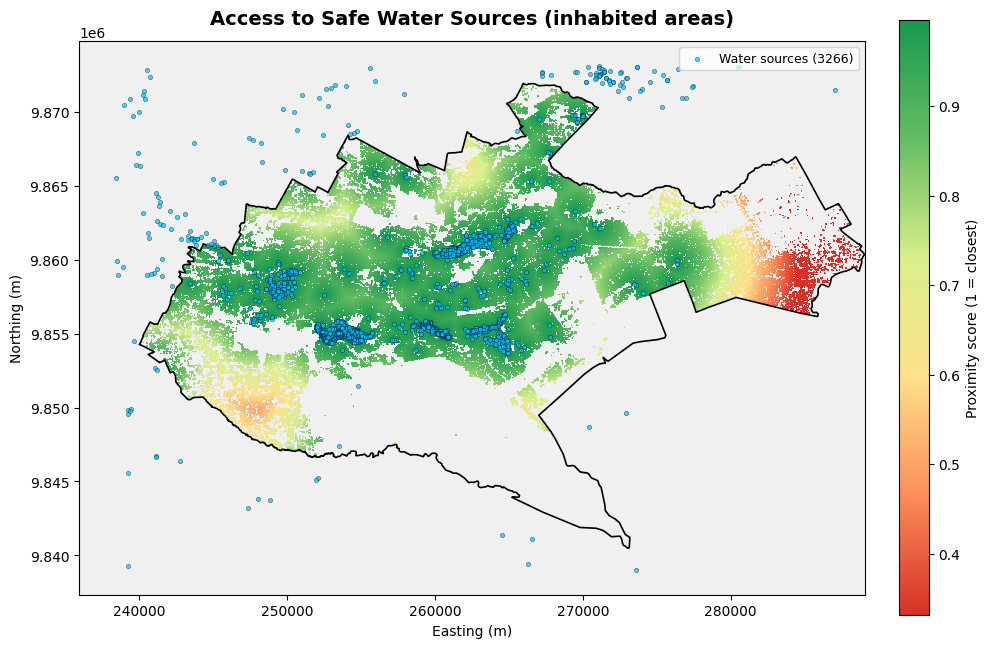

In [6]:
water = load_geojson('3_adaptivity/water_sources_nairobi.geojson')

water_proximity = compute_proximity(water, grid_pop)   # normalise over inhabited area

fig, ax = plt.subplots(figsize=(10, 9))
plot_inhabited(water_proximity, grid,
           'Access to Safe Water Sources (inhabited areas)',
           cbar_label='Proximity score (1 = closest)', ax=ax)
plot_points_overlay(water, grid, ax, color='deepskyblue', size=10,
                    label=f'Water sources ({len(water)})')
plt.tight_layout()
plt.show();

## 4 · Urban green space accessibility
Parks, gardens, and forested areas provide shade and evapotranspiration cooling. This layer measures proximity to green-space centroids extracted from OSM.

  Loaded 3_adaptivity/green_spaces_nairobi.geojson: 3119 features


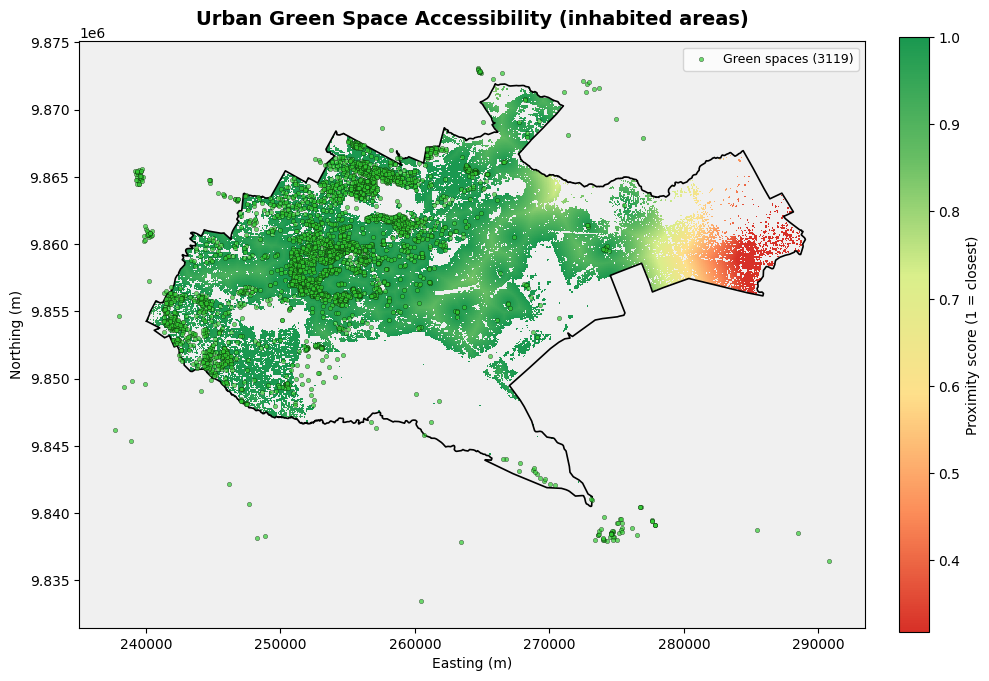

In [7]:
green = load_geojson('3_adaptivity/green_spaces_nairobi.geojson')

green_proximity = compute_proximity(green, grid_pop)   # normalise over inhabited area

fig, ax = plt.subplots(figsize=(10, 9))
plot_inhabited(green_proximity, grid,
           'Urban Green Space Accessibility (inhabited areas)',
           cbar_label='Proximity score (1 = closest)', ax=ax)
plot_points_overlay(green, grid, ax, color='limegreen', size=10,
                    label=f'Green spaces ({len(green)})')
plt.tight_layout()
plt.show();

## 5 · Mobility & evacuation potential
Road network density reflects how easily residents can move to cooler areas or reach emergency services. We combine `major_roads.geojson` and `street_edges.geojson` and compute a Gaussian-smoothed road density surface. 

  Loaded 3_adaptivity/roads.geojson: 46233 features
  Combined road segments: 46233


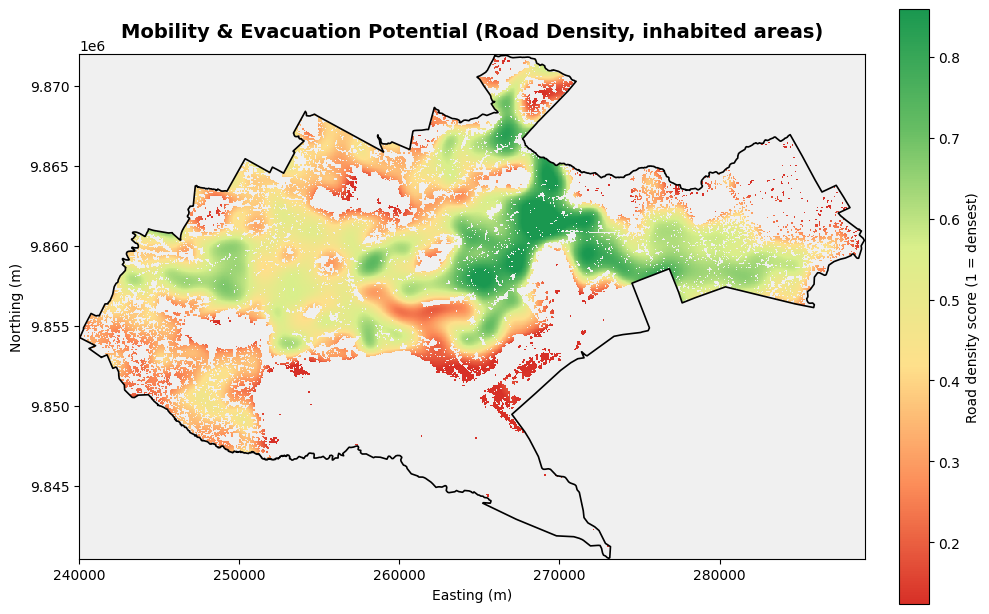

In [8]:
roads = load_geojson('3_adaptivity/roads.geojson')
all_roads = gpd.GeoDataFrame(roads)

print(f"  Combined road segments: {len(all_roads)}")

mobility = compute_road_density(all_roads, grid_pop, bandwidth_m=500)   # normalise over inhabited area

fig, ax = plt.subplots(figsize=(10, 9))
plot_inhabited(mobility, grid,
           'Mobility & Evacuation Potential (Road Density, inhabited areas)',
           cbar_label='Road density score (1 = densest)', ax=ax)
plt.tight_layout()
plt.show()

## 6 · Cooling centre proximity
Public buildings that can serve as cooling refuges - libraries, community centres, places of worship, and social facilities - are mapped from OSM.

  Loaded 3_adaptivity/cooling_centers_nairobi.geojson: 1849 features


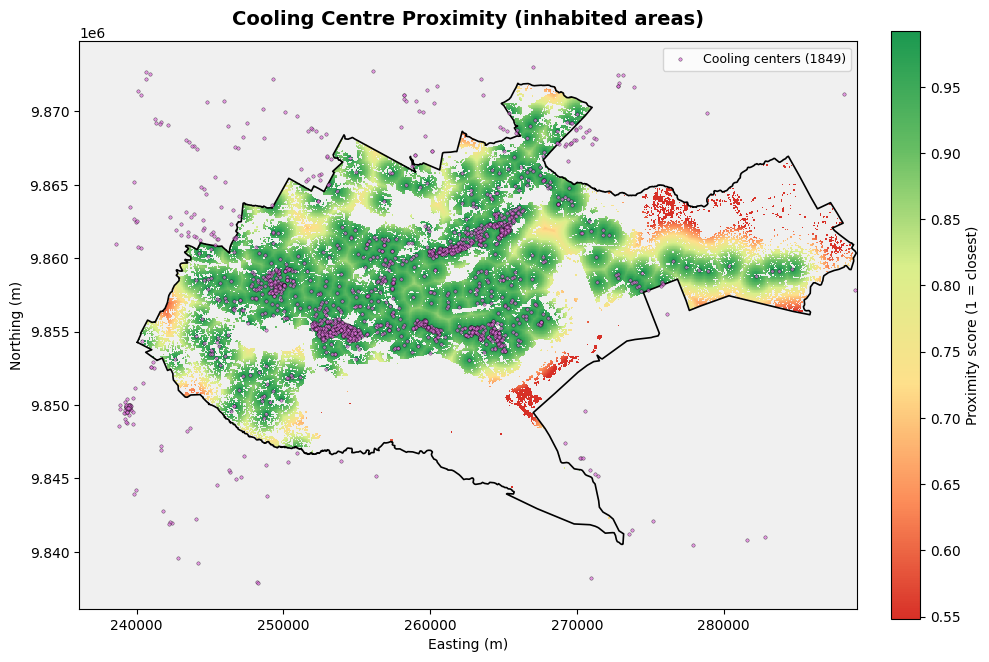

In [9]:
cooling = load_geojson('3_adaptivity/cooling_centers_nairobi.geojson')

cooling_proximity = compute_proximity(cooling, grid_pop)   # normalise over inhabited area

fig, ax = plt.subplots(figsize=(10, 9))
plot_inhabited(cooling_proximity, grid,
           'Cooling Centre Proximity (inhabited areas)',
           cbar_label='Proximity score (1 = closest)', ax=ax)
plot_points_overlay(cooling, grid, ax, color='orchid', size=6,
                    label=f'Cooling centers ({len(cooling)})')
plt.tight_layout()
plt.show()

---
## Composite Adaptive Capacity Index
We combine all six normalised layers into a single Adaptive Capacity score using an **equal-weight average** ($w_i = 1/6$). The weights can be adjusted in future iterations based on domain expertise or sensitivity analysis.

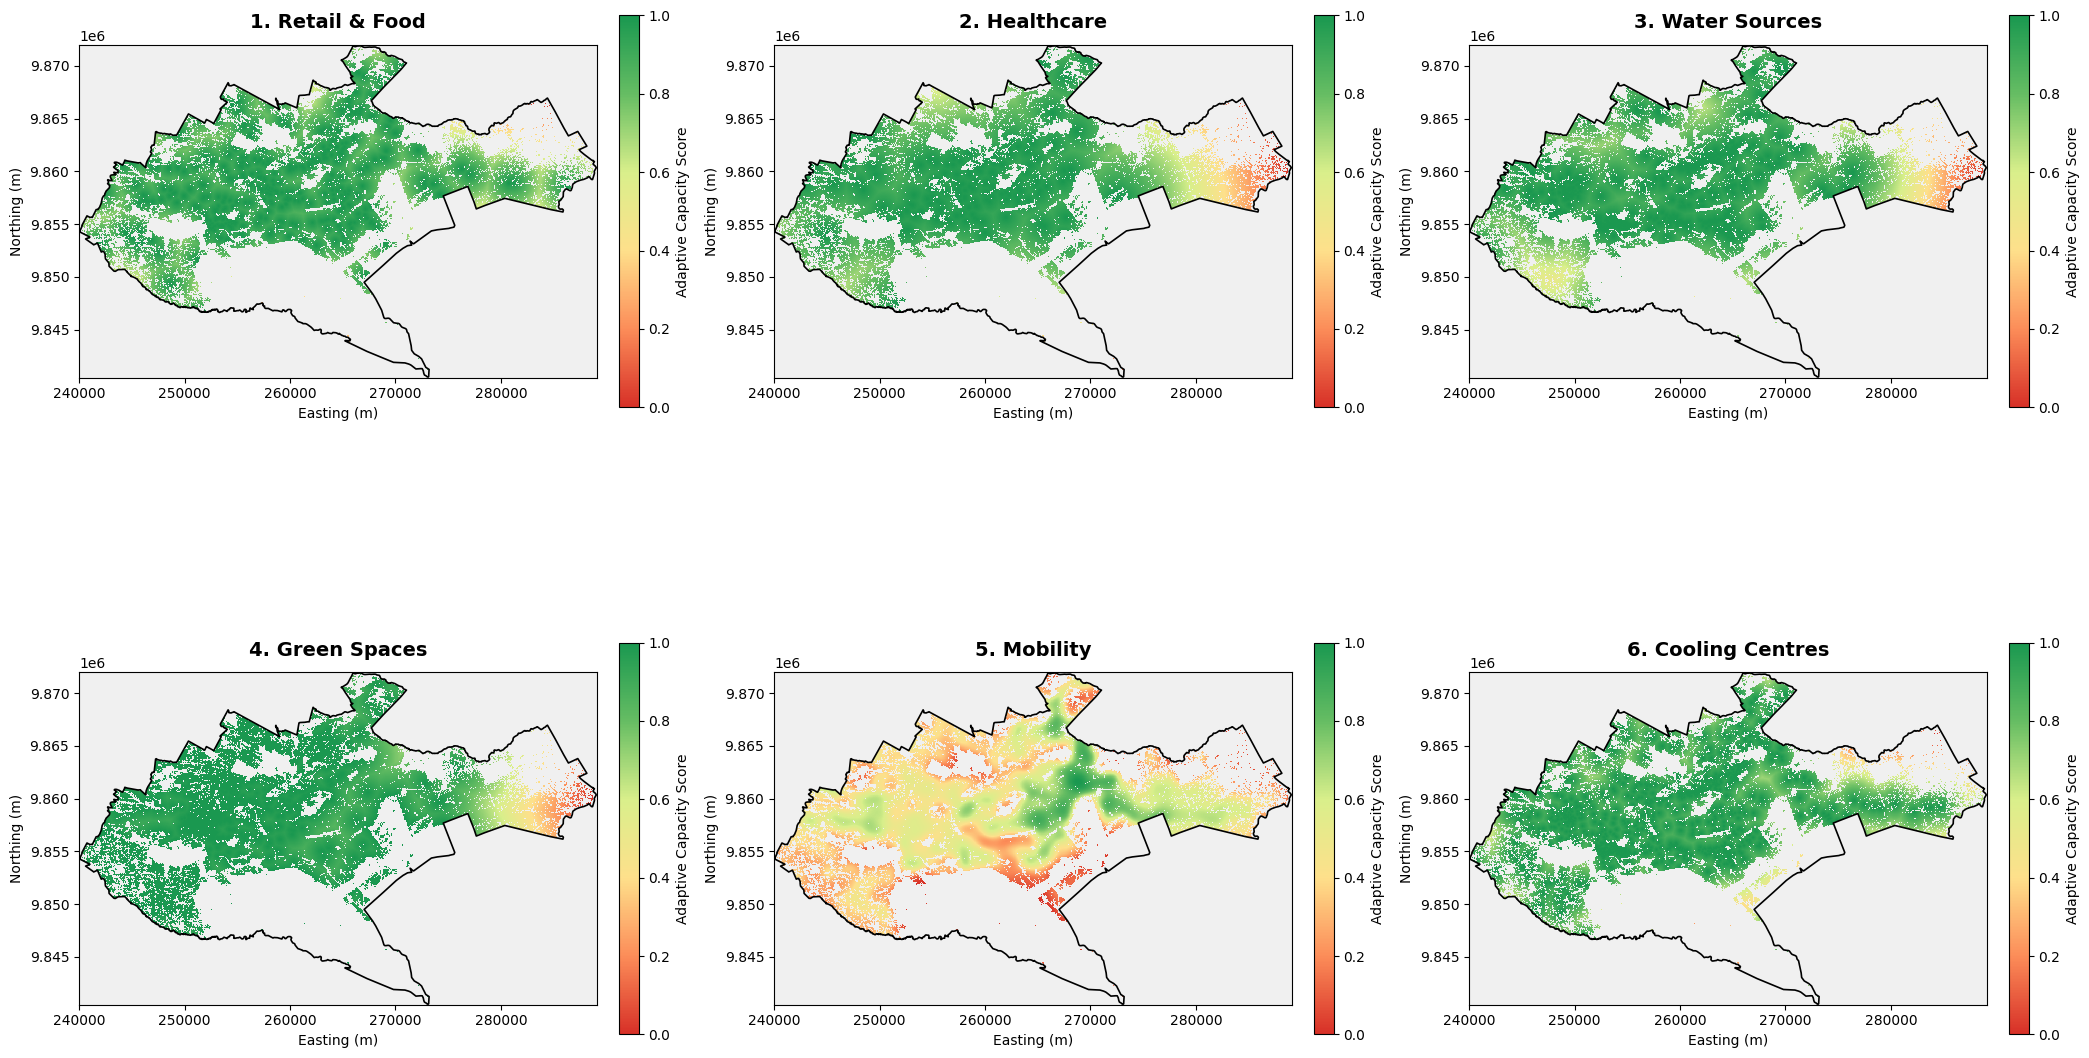

In [10]:
# --- Overview: all 6 individual layers side-by-side (inhabited areas) -------
layers_dict = {
    '1. Retail & Food':   mask_uninhabited(retail_proximity),
    '2. Healthcare':      mask_uninhabited(health_proximity),
    '3. Water Sources':   mask_uninhabited(water_proximity),
    '4. Green Spaces':    mask_uninhabited(green_proximity),
    '5. Mobility':        mask_uninhabited(mobility),
    '6. Cooling Centres': mask_uninhabited(cooling_proximity),
}

fig = plot_all_layers(layers_dict, grid)

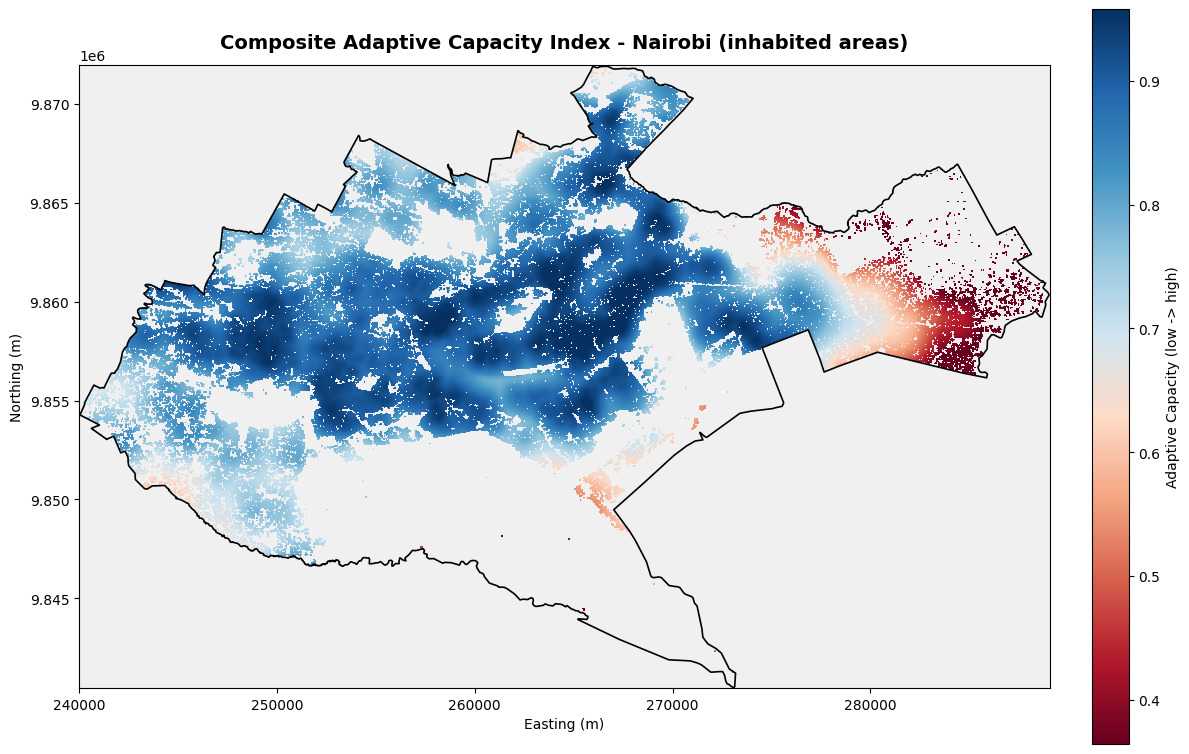

In [11]:
# --- Compute composite (equal weights) ----------------------------
layers_list = [
    retail_proximity,
    health_proximity,
    water_proximity,
    green_proximity,
    mobility,
    cooling_proximity,
]

# Equal weights: 1/6 each
ac_composite = compute_composite(layers_list)

# --- Plot the final Adaptive Capacity map (inhabited areas) -------
fig, ax = plt.subplots(figsize=(12, 10))
plot_inhabited(
    ac_composite, grid,
    'Composite Adaptive Capacity Index - Nairobi (inhabited areas)',
    cmap=COMPOSITE_CMAP, ax=ax,
    cbar_label='Adaptive Capacity (low -> high)'
)
plt.tight_layout()
plt.show()

Composite AC - min: 0.000  max: 1.000  mean: 0.812  std: 0.137


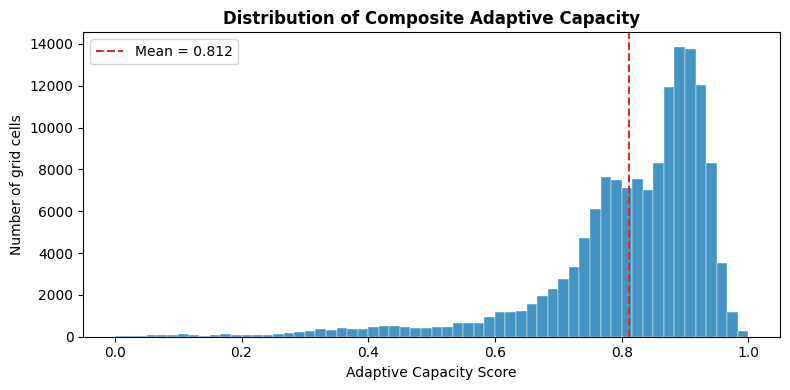

In [12]:
# --- Summary statistics ---
vals = ac_composite[~np.isnan(ac_composite)]
print(f"Composite AC - min: {vals.min():.3f}  max: {vals.max():.3f}  "
      f"mean: {vals.mean():.3f}  std: {vals.std():.3f}")

# Histogram
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(vals, bins=60, color='#4393c3', edgecolor='white', linewidth=0.3)
ax.set_xlabel('Adaptive Capacity Score')
ax.set_ylabel('Number of grid cells')
ax.set_title('Distribution of Composite Adaptive Capacity', fontweight='bold')
ax.axvline(vals.mean(), color='#d73027', linestyle='--', label=f'Mean = {vals.mean():.3f}')
ax.legend()
plt.tight_layout()
plt.show()

In [13]:
# Export AC maps for the webapp:
#   - raw PNG (full grid)  -> drives the live composite feature
#   - styled PNG, MASKED to inhabited pixels -> what the dashboard displays
WEBAPP_MAPS = os.path.join(PROJECT_ROOT, 'webapp', 'public', 'maps')

ac_layers = {
    "retail_proximity":   retail_proximity,
    "health_proximity":   health_proximity,
    "water_proximity":    water_proximity,
    "green_proximity":    green_proximity,
    "cooling_proximity":  cooling_proximity,
    "mobility_proximity": mobility,
}
for name, arr in ac_layers.items():
    export_raw_for_web(arr, name, WEBAPP_MAPS)
    export_raster_for_web(mask_uninhabited(arr), grid, name,
                          cmap=PROXIMITY_CMAP, vmin=0, vmax=1, output_dir=WEBAPP_MAPS)
print("Exported AC maps (raw + inhabited-masked styled) -> webapp/public/maps")


Exported raw data for 'retail_proximity' to c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-ETHOS\Nairobi_Heat_Vulnerability_Assessment\webapp\public\maps\retail_proximity_raw.png
Exported 'retail_proximity' to c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-ETHOS\Nairobi_Heat_Vulnerability_Assessment\webapp\public\maps
Exported raw data for 'health_proximity' to c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-ETHOS\Nairobi_Heat_Vulnerability_Assessment\webapp\public\maps\health_proximity_raw.png
Exported 'health_proximity' to c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-ETHOS\Nairobi_Heat_Vulnerability_Assessment\webapp\public\maps
Exported raw data for 'water_proximity' to c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-ETHOS\Nairobi_Heat_Vulnerability_Assessment\webapp\public\maps\water_proximity_raw.png
Exported 'water_proximity' to c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-ETHOS\Nairobi_Heat_Vulnerability_Assessment\webapp\public\

In [14]:
# --- Save numeric grids for the statistics notebook ------------------------
# GeoTIFFs in results/web/data/*.tif keep the REAL values (unlike the PNGs),
# so 4_statistics_analysis reads these instead of recomputing from raw data.
# All layers are already restricted to inhabited pixels (computed on grid_pop).
from src.export_web_maps import export_grid_data

# Proximity SCORES (0-1, 1 = closest) + road density + composite
export_grid_data(retail_proximity,  grid, "retail_proximity")
export_grid_data(health_proximity,  grid, "health_proximity")
export_grid_data(water_proximity,   grid, "water_proximity")
export_grid_data(green_proximity,   grid, "green_proximity")
export_grid_data(cooling_proximity, grid, "cooling_proximity")
export_grid_data(mobility,          grid, "mobility_proximity")
export_grid_data(ac_composite,      grid, "adaptive_capacity_composite")

# Real DISTANCE to nearest facility (metres), inhabited pixels only
export_grid_data(compute_distance(retail,  grid_pop), grid, "retail_distance")
export_grid_data(compute_distance(health,  grid_pop), grid, "health_distance")
export_grid_data(compute_distance(water,   grid_pop), grid, "water_distance")
export_grid_data(compute_distance(green,   grid_pop), grid, "green_distance")
export_grid_data(compute_distance(cooling, grid_pop), grid, "cooling_distance")

print("Saved adaptive-capacity grids (scores + distances) -> results/web/data/")

Saved grid data 'retail_proximity' -> c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-ETHOS\Nairobi_Heat_Vulnerability_Assessment\results\web\data\retail_proximity.tif
Saved grid data 'health_proximity' -> c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-ETHOS\Nairobi_Heat_Vulnerability_Assessment\results\web\data\health_proximity.tif
Saved grid data 'water_proximity' -> c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-ETHOS\Nairobi_Heat_Vulnerability_Assessment\results\web\data\water_proximity.tif
Saved grid data 'green_proximity' -> c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-ETHOS\Nairobi_Heat_Vulnerability_Assessment\results\web\data\green_proximity.tif
Saved grid data 'cooling_proximity' -> c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-ETHOS\Nairobi_Heat_Vulnerability_Assessment\results\web\data\cooling_proximity.tif
Saved grid data 'mobility_proximity' -> c:\Users\Surface\Desktop\EPFL\MASTER\MA2_2025_2026\PDS-ETHOS\Nairobi_Heat_Vulnerability